# Train-AT-f / Eval-AT-f Hidden-Layer Perturbation -- CCISI (Ts=0.5, learnable tau)

## Overview

For each perturbation level `f`, train a fresh SNN (with learnable
tau, no delays) on the CCISI synthetic task while applying hidden-layer
spike perturbation at level `f` inside the forward pass. The same
model is then evaluated at the same `f`.

Sample rate: Ts = 0.5 ms. Input scaling and PSP filter length (100
taps to cover 50 ms) are set per `sample_rate.md`.

## 1. Imports and Setup

In [1]:
import os
import sys
import json
import random
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import h5py

import slayerSNN as snn

MS = 1e-3  # Millisecond constant

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. SLAYER and Training Parameters

SLAYER neuron and simulation descriptors for the 2000-rate (Ts=0.5 ms)
setup. Ts in `SIM_PARAMS` is in milliseconds. Per `sample_rate.md`:
- Input spikes are scaled by `1/Ts` inside the network so SLAYER's
  internal `1/Ts` spike convention is matched (Bug 1 fix).


In [2]:
# --- SLAYER neuron and simulation descriptors (2000-rate setup) ---
# Ts = 0.5 ms / step => 2000 Hz sampling; tSample = 1000 ms window.
SIM_PARAMS = {"Ts": 0.5, "tSample": 1000}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 1,
    "tauSr": 1,
    "tauRho": 1,
    "tauRef": 1,
    "scaleRef": 2,
    "scaleRho": 1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE = (0.6, 0.75)
TEST_RANGE = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS = 100
EPOCHS = 301
BATCH_SIZE = 32
LEARNING_RATE = 0.001
SEED = 42

# --- Hidden-perturbation sweep (train at f AND eval at f) ---
F_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUM_REPEATS = 3  # repeated evaluations per f to get error bars

## 3. Load CCISI Dataset

Load the CCISI spike-train dataset from the local HDF5 file.
Each sample has shape `(num_neurons, T)` with binary 0/1 spike values;
the network rescales them to SLAYER's `1/Ts` convention internally.

In [3]:
def load_ccisi_data(data_file: str = "ccisi_dataset.h5"):
    """Load CCISI dataset from HDF5 file.

    Args:
        data_file: Path to the HDF5 file.

    Returns:
        Tuple of (X, Y, firing_rates, isis) arrays.
    """
    with h5py.File(data_file, "r") as f:
        X = f["X"][:]
        Y = f["Y"][:].ravel()
        firing_rates = f["firing_rates"][:] if "firing_rates" in f else None
        isis = f["isis"][:] if "isis" in f else None

    print(f"Loaded {data_file}: X={X.shape}, Y={Y.shape}")
    print(f"Classes: {np.unique(Y)}, Time steps: {X.shape[2]}")
    return X, Y, firing_rates, isis


X_all, Y_all, firing_rates_all, isis_all = load_ccisi_data("ccisi_dataset.h5")
NUM_NEURONS = X_all.shape[1]
NUM_CLASSES = len(np.unique(Y_all))
print(f"Network config: {NUM_NEURONS} input neurons, {NUM_CLASSES} classes")

Loaded ccisi_dataset.h5: X=(3598, 20, 2000), Y=(3598,)
Classes: [0 1], Time steps: 2000
Network config: 20 input neurons, 2 classes


## 4. Hidden-Layer Spike Perturbation

Given a hidden layer's spike output, randomly relocate a fraction `f`
of each neuron's spikes while preserving spike count per neuron. The
vectorised GPU implementation runs entirely on-device (no CPU round-trip),
which matters here because perturbation runs on every training batch.

In [4]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes (numpy reference).

    Kept for documentation / numpy-only callers. The training and evaluation
    paths use the vectorised GPU version ``perturb_hidden_batch`` below.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).
        max_attempts: Max placement retries per spike.

    Returns:
        Perturbed spike train with the same shape.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        num_to_move = int(len(spike_times) * f)
        if num_to_move == 0:
            continue

        chosen = np.random.choice(spike_times, size=num_to_move, replace=False)
        new_train[neuron_idx, chosen] = 0

        placed = 0
        for _ in range(max_attempts * num_to_move):
            if placed >= num_to_move:
                break
            new_t = np.random.randint(0, T)
            if new_train[neuron_idx, new_t] == 0:
                new_train[neuron_idx, new_t] = 1
                placed += 1

    return new_train


@torch.no_grad()
def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float = 0.0,
) -> torch.Tensor:
    """Vectorised GPU-side partial spike relocation.

    For each (batch, neuron), a fraction *f* of the existing spikes are
    removed and replaced with the same number of spikes placed at randomly
    chosen previously-unoccupied time bins. Spike count per neuron is
    preserved exactly. All operations stay on the input tensor's device,
    avoiding the CPU/numpy round-trip that dominates training cost when
    perturbation runs on every batch.

    Args:
        hidden_spikes: SLAYER-format tensor of shape (B, C, 1, 1, T). At Ts < 1,
            SLAYER emits spike values of 1/Ts; the > 0.5 threshold below works
            for any sane Ts.
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).

    Returns:
        Perturbed tensor with the same shape, dtype, and device.
    """
    if f <= 0:
        return hidden_spikes

    B, C, H, W, T = hidden_spikes.shape
    x = hidden_spikes.view(B, C, T)
    is_spike = x > 0.5

    n_spikes = is_spike.sum(dim=-1, keepdim=True)
    num_to_move = (n_spikes.float() * f).floor().long()

    key = torch.rand_like(x)
    key = torch.where(is_spike, key, torch.full_like(key, 2.0))
    rank = key.argsort(dim=-1).argsort(dim=-1)
    remove_mask = rank < num_to_move
    keep_mask = is_spike & ~remove_mask

    available = ~keep_mask
    key2 = torch.rand_like(x)
    key2 = torch.where(available, key2, torch.full_like(key2, 2.0))
    rank2 = key2.argsort(dim=-1).argsort(dim=-1)
    add_mask = rank2 < num_to_move

    # Preserve SLAYER's 1/Ts spike amplitude (not just binary 1.0).
    spike_value = x[is_spike].max() if is_spike.any() else torch.tensor(1.0, device=x.device)
    new_spikes = (keep_mask | add_mask).to(hidden_spikes.dtype) * spike_value
    return new_spikes.view(B, C, H, W, T)

## 5. Dataset and Data Splitting

A `Dataset` wrapper and a helper that splits the data into train /
validation / test loaders. The data is stored unperturbed; perturbation
happens inside the network forward pass.

In [5]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(split_range: tuple[float, float], total: int) -> np.ndarray:
    """Return integer indices for the given fractional range."""
    return np.arange(int(split_range[0] * total), int(split_range[1] * total))


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 32,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Split data and return train / val / test DataLoaders.

    Inputs are stored unperturbed; the hidden-layer perturbation is applied
    inside the network forward pass, parameterised by ``f``.
    """
    train_idx = get_split_indices(TRAIN_RANGE, len(X))
    val_idx = get_split_indices(VAL_RANGE, len(X))
    test_idx = get_split_indices(TEST_RANGE, len(X))

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds = SpikeDataset(X[val_idx], Y[val_idx])
    test_ds = SpikeDataset(X[test_idx], Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"Split sizes -- Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A single-hidden-layer SLAYER SNN with a **learnable PSP filter** (tau),
no delays (the SGD tau-only variant).

Key implementation details:
- `_prepare_input` scales binary inputs by `1/Ts` to match SLAYER's
  internal spike convention (`sample_rate.md` Bug 1 fix).
- `_apply_perturbation` wraps the GPU perturbation in a straight-through
  estimator (`how_to_perturb_hidden_layer_during_training.md`) so that
  gradients flow back through to the upstream layers even when training
  at f > 0. Without this, fc1 / psp_filter would receive zero gradient.
- `forward(x, f)` is the single entry point used for both training and
  evaluation. Pass `f=train_f` during training and `f=eval_f` at test.

In [6]:
class CCISINetwork(nn.Module):
    """SLAYER SNN with learnable PSP filter (tau), no delays.

    Hidden-layer spike perturbation is built into ``forward`` via a
    straight-through estimator so gradients flow through to the
    upstream layers even when training at f > 0.
    """

    def __init__(
        self,
        num_neurons: int,
        num_classes: int,
        hidden_units: int = 100,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer

        self.fc1 = nn.utils.weight_norm(
            slayer.dense(num_neurons, hidden_units), name="weight",
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight",
        )

        # filterLength = 100 at Ts=0.5 covers the same 50 ms window as
        # filterLength = 50 at Ts=1.
        self.psp_filter = slayer.pspFilter(
            nFilter=1, filterLength=100, filterScale=1,
        )
        self._initialize_alpha_filter()

    def _initialize_alpha_filter(self) -> None:
        """Seed the learnable PSP filter with an alpha-function shape."""
        tau = 50 * MS
        Ts = self.slayer.simulation["Ts"] * MS
        filt_len = self.psp_filter.weight.shape[-1]

        alpha_kernel = np.array([
            t / tau * np.exp(1 - t / tau)
            for t in np.arange(0, filt_len * Ts, Ts)
        ])
        if np.max(np.abs(alpha_kernel)) > 0:
            alpha_kernel /= np.max(np.abs(alpha_kernel))

        with torch.no_grad():
            self.psp_filter.weight.data = torch.FloatTensor(
                np.flip(alpha_kernel).copy()
            ).reshape(self.psp_filter.weight.shape)

    def get_tau(self) -> torch.Tensor:
        """Estimate the effective tau (peak position) of the learned filter."""
        weights = self.psp_filter.weight.data.squeeze().cpu().numpy()
        weights = np.flip(weights)
        if len(weights) > 0:
            peak_idx = np.argmax(np.abs(weights))
            estimated_tau = 3 * peak_idx * self.slayer.simulation["Ts"] * MS
            return torch.tensor(max(estimated_tau, 10 * MS))
        return torch.tensor(50 * MS)

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure 5-D NCHWT on device and scale 0/1 to SLAYER's 1/Ts convention.

        Fix for sample_rate.md Bug 1: our HDF5 datasets store binary 0/1
        spike trains but SLAYER's internal spike value is 1/Ts. Without this
        scaling, input-side PSPs come out at half magnitude at Ts=0.5.
        """
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device) / self.slayer.simulation["Ts"]

    def _first_layer(self, x: torch.Tensor) -> torch.Tensor:
        """Input -> hidden spikes (learnable PSP + fc1 + spike)."""
        x_filtered = self.psp_filter(x)
        return self.slayer.spike(self.fc1(x_filtered))

    def _second_layer(self, hidden_spikes: torch.Tensor) -> torch.Tensor:
        """Hidden spikes -> output spikes (standard PSP + fc2 + spike)."""
        return self.slayer.spike(self.fc2(self.slayer.psp(hidden_spikes)))

    def _apply_perturbation(
        self,
        hidden_spikes: torch.Tensor,
        f: float,
    ) -> torch.Tensor:
        """Straight-through estimator wrapper around perturb_hidden_batch.

        Forward value = perturbed; backward gradient = identity through
        ``hidden_spikes``. Without this, the perturbation breaks the
        autograd graph and upstream layers (fc1, psp_filter) get zero
        gradient during training.
        """
        if f <= 0:
            return hidden_spikes
        perturbed = perturb_hidden_batch(hidden_spikes, f)
        return hidden_spikes + (perturbed - hidden_spikes).detach()

    def forward(self, x: torch.Tensor, f: float = 0.0) -> torch.Tensor:
        """Forward pass with hidden-layer perturbation at level *f*.

        Args:
            x: Input spike trains (numpy or tensor, 3-D or 5-D).
            f: Perturbation fraction. 0 disables perturbation entirely.

        Returns:
            Output spike tensor.
        """
        x = self._prepare_input(x)
        hidden_spikes = self._first_layer(x)
        hidden_spikes = self._apply_perturbation(hidden_spikes, f)
        return self._second_layer(hidden_spikes)

## 7. Training Loop

Train the network using SLAYER ProbSpikes loss with the Nadam optimiser.
`train_f` is passed to every forward call so perturbation happens both
in the training and validation passes (the model is being asked to learn
a representation that is robust to that level of hidden-layer noise).
The best checkpoint (lowest validation loss) is restored at the end.

In [7]:
def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_neurons: int,
    num_classes: int,
    train_f: float,
    hidden_units: int = 100,
    epochs: int = 301,
    lr: float = 0.001,
    seed: int = 42,
) -> tuple["CCISINetwork", dict]:
    """Train the network with hidden-layer perturbation at level ``train_f``.

    Args:
        train_loader: Training DataLoader (unperturbed inputs).
        val_loader: Validation DataLoader (unperturbed inputs).
        num_neurons: Number of input neurons.
        num_classes: Number of output classes.
        train_f: Perturbation fraction applied inside the network during training.
        hidden_units: Hidden layer size.
        epochs: Number of training epochs.
        lr: Learning rate.
        seed: Random seed for reproducibility.

    Returns:
        Tuple of (trained network, training log dict).
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    net = CCISINetwork(num_neurons, num_classes, hidden_units).to(device)

    loss_fn = snn.spikeLoss.spikeLoss({
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {"error": {"type": "ProbSpikes"}},
    }).to(device)

    optimizer = snn.utils.optim.Nadam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.5,
    )

    best_val_loss = float("inf")
    best_model_state = None
    tau_history: list[float] = []

    log = {"epoch": [], "train_loss": [], "val_loss": [], "tau": []}

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc=f"Train f={train_f:.2f}") as pbar:
        for epoch in range(epochs):
            net.train()
            epoch_loss = 0.0
            batch_count = 0

            for x_batch, y_batch in train_loader:
                if x_batch.dim() == 3:
                    x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device).long()

                outputs = net(x_batch, f=train_f)
                loss = loss_fn.probSpikes(outputs, y_batch)
                epoch_loss += loss.item()
                batch_count += 1

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                pbar.update(1)

            net.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    if x_batch.dim() == 3:
                        x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                    x_batch = x_batch.to(device).float()
                    y_batch = y_batch.to(device).long()
                    outputs = net(x_batch, f=train_f)
                    val_loss += loss_fn.probSpikes(outputs, y_batch).item()

            val_loss /= len(val_loader)
            epoch_loss /= batch_count
            tau_val = net.get_tau().item() / MS
            tau_history.append(tau_val)

            log["epoch"].append(epoch)
            log["train_loss"].append(epoch_loss)
            log["val_loss"].append(val_loss)
            log["tau"].append(tau_val)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {k: v.clone() for k, v in net.state_dict().items()}

            scheduler.step()
            pbar.set_postfix(
                epoch=epoch + 1,
                val_loss=f"{val_loss:.4f}",
                best=f"{best_val_loss:.4f}",
                tau=f"{tau_val:.1f}ms",
            )

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    log["tau_history"] = tau_history
    return net, log

## 8. Testing with Hidden-Layer Perturbation

Evaluate a trained model with perturbation at level *f* (matching the
`train_f` used to train it). `eval_repeated` runs the evaluation
`NUM_REPEATS` times with different random seeds for error bars.

In [8]:
def test_with_hidden_perturbation(
    net: CCISINetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer perturbation at level *f*."""
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            if x_batch.dim() == 3:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3)
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device)

            outputs = net(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def eval_repeated(
    net: CCISINetwork,
    test_loader: DataLoader,
    f: float,
    num_repeats: int = 3,
    base_seed: int = 0,
) -> dict:
    """Run multiple stochastic evaluations to get mean/std accuracy."""
    accuracies: list[float] = []
    for repeat in range(num_repeats):
        torch.manual_seed(base_seed + repeat)
        np.random.seed(base_seed + repeat)
        accuracies.append(test_with_hidden_perturbation(net, test_loader, f=f))
    return {
        "mean": float(np.mean(accuracies)),
        "std": float(np.std(accuracies)),
        "values": [float(a) for a in accuracies],
    }

## 9. Visualisation Utilities

Plot training curves for one f value and the accuracy-vs-f sweep across
all trained models.

In [9]:
def plot_training_curves(log: dict, title_suffix: str = "") -> None:
    """Plot training/validation loss and tau evolution."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(log["epoch"], log["train_loss"], "o-", label="Train", markersize=2)
    axes[0].plot(log["epoch"], log["val_loss"], "s-", label="Val", markersize=2)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"Loss {title_suffix}")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(log["tau_history"])
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Tau (ms)")
    axes[1].set_title(f"Tau {title_suffix}")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_curve(
    sweep_results: dict,
    save_path: str,
) -> None:
    """Plot accuracy vs hidden perturbation level f (train-at-f / eval-at-f)."""
    f_vals = sorted(sweep_results.keys())
    means = [sweep_results[f]["mean"] for f in f_vals]
    stds = [sweep_results[f]["std"] for f in f_vals]

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        f_vals, means, yerr=stds, fmt="o-", capsize=5, capthick=2,
        color="tab:blue", label="SGD (learnable tau)",
    )
    plt.xlabel("Perturbation level f (train and eval)")
    plt.ylabel("Test accuracy")
    plt.title("CCISI -- SGD (tau) (Ts=0.5) -- train-at-f / eval-at-f hidden perturbation")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, mean in zip(f_vals, means):
        plt.annotate(
            f"{mean:.3f}", (f_val, mean),
            textcoords="offset points", xytext=(0, 12), ha="center", fontsize=9,
        )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Figure saved to {save_path}")

## 10. Run: Train AT f / Evaluate AT f for Each Perturbation Level

For each `f` in `F_VALUES` train a fresh model with hidden-layer
perturbation set to `f`, then evaluate that same model at the same `f`.
Each trained checkpoint is written to `data/` so it can be re-loaded
later without re-training.

In [10]:
os.makedirs("data", exist_ok=True)
os.makedirs("log", exist_ok=True)

# Build DataLoaders once -- inputs are unperturbed; the hidden-layer
# perturbation is parameterised by the f passed to the network forward.
train_loader, val_loader, test_loader = build_dataloaders(
    X_all, Y_all, batch_size=BATCH_SIZE,
)

sweep_results: dict = {}
training_logs: dict = {}

for f_val in F_VALUES:
    print(f"\n=== Train and eval at f = {f_val:.2f} ===")

    net, log = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        num_neurons=NUM_NEURONS,
        num_classes=NUM_CLASSES,
        train_f=f_val,
        hidden_units=HIDDEN_UNITS,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        seed=SEED,
    )

    model_path = f"data/ccisi_tau_f{int(round(f_val * 100)):03d}_trained.pt"
    torch.save(net.state_dict(), model_path)

    eval_seed = SEED + int(round(f_val * 100))
    stats = eval_repeated(
        net, test_loader, f=f_val,
        num_repeats=NUM_REPEATS, base_seed=eval_seed,
    )
    sweep_results[f_val] = stats
    training_logs[f_val] = log

    print(
        f"  f={f_val:.2f}: accuracy = {stats['mean']:.4f} +/- {stats['std']:.4f}"
        f"  (model saved to {model_path})"
    )

# Reference handle to the last-trained network (for downstream analysis cells).
last_net = net
last_log = log

Split sizes -- Train: 2158, Val: 540, Test: 540

=== Train and eval at f = 0.00 ===


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Train f=0.00:   0%|          | 0/20468 [00:00<?, ?it/s]d:\IC_2025\IRP\workspace\venv\Lib\site-packages\slayersnn-0.0.0-py3.11.egg\slayerSNN\optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1691.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
Train f=0.00: 100%|██████████| 20468/20468 [26:34<00:00, 12.84it/s, best=0.0861, epoch=301, tau=97.5ms, val_loss=0.0869]
d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated

  f=0.00: accuracy = 0.9963 +/- 0.0000  (model saved to data/ccisi_tau_f000_trained.pt)

=== Train and eval at f = 0.20 ===


Train f=0.20: 100%|██████████| 20468/20468 [42:15<00:00,  8.07it/s, best=0.1572, epoch=301, tau=91.5ms, val_loss=0.1623]  


  f=0.20: accuracy = 0.9747 +/- 0.0009  (model saved to data/ccisi_tau_f020_trained.pt)

=== Train and eval at f = 0.40 ===


...

  f=0.60: accuracy = 0.9889 +/- 0.0015  (model saved to data/ccisi_tau_f060_trained.pt)

=== Train and eval at f = 0.80 ===


Train f=0.80: 100%|██████████| 20468/20468 [24:51<00:00, 13.72it/s, best=0.2986, epoch=301, tau=115.5ms, val_loss=0.3069]


  f=0.80: accuracy = 0.9364 +/- 0.0038  (model saved to data/ccisi_tau_f080_trained.pt)

=== Train and eval at f = 1.00 ===


Train f=1.00: 100%|██████████| 20468/20468 [25:09<00:00, 13.56it/s, best=0.1528, epoch=301, tau=115.5ms, val_loss=0.1565]


  f=1.00: accuracy = 0.9710 +/- 0.0023  (model saved to data/ccisi_tau_f100_trained.pt)


## 11. Plot Training Curves

Visualise loss, tau evolution for the f = 0 baseline run.

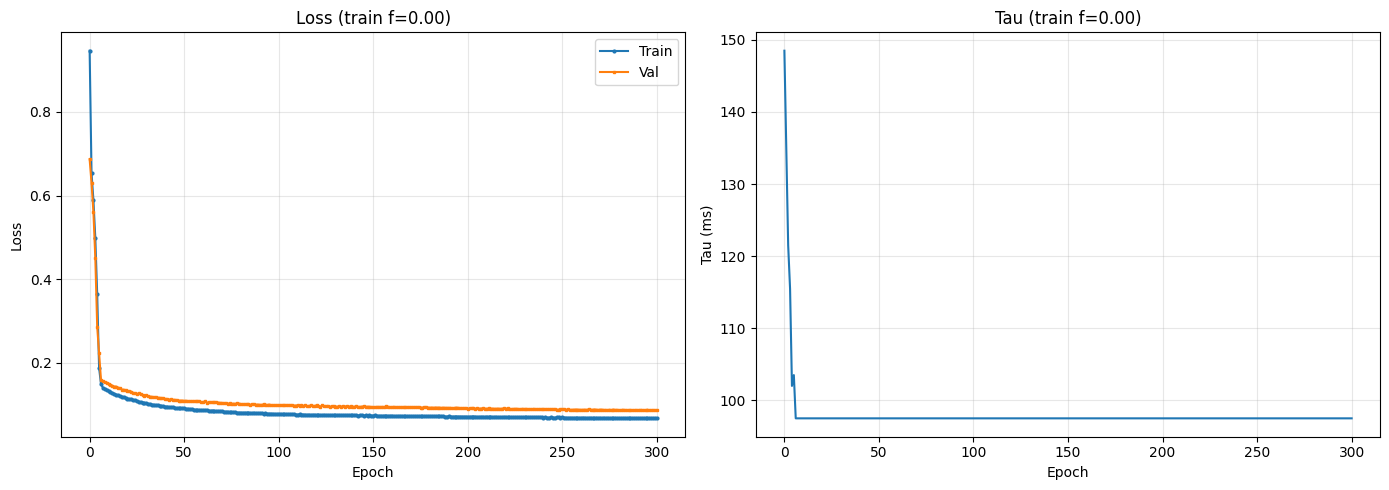

In [11]:
# Plot the f = 0 training curves as a baseline reference.
baseline_f = 0.0
if baseline_f in training_logs:
    plot_training_curves(training_logs[baseline_f], title_suffix=f"(train f={baseline_f:.2f})")
else:
    any_f = next(iter(training_logs))
    plot_training_curves(training_logs[any_f], title_suffix=f"(train f={any_f:.2f})")

## 12. Plot Accuracy vs Perturbation Level

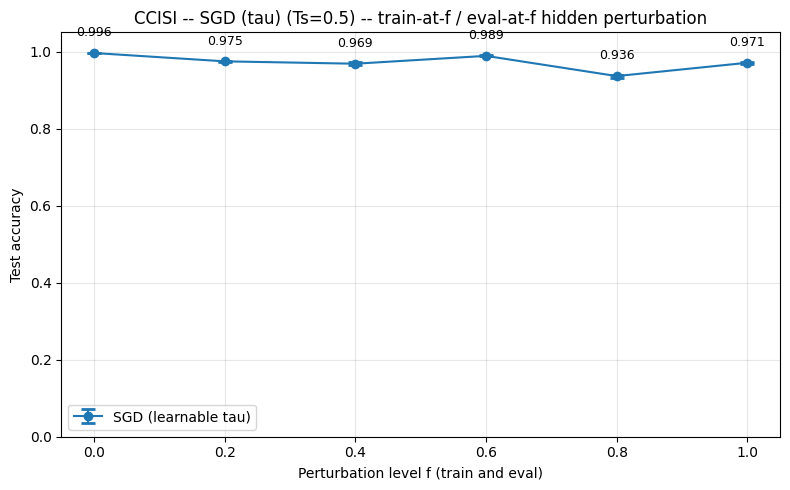

Figure saved to log/ccisi_tau_hidden_perturbation.png


In [12]:
plot_hidden_perturbation_curve(
    sweep_results,
    save_path="log/ccisi_tau_hidden_perturbation.png",
)

## 13. Save Results

Persist the per-f accuracy statistics and the full per-f training logs
as JSON for later cross-Ts / cross-variant comparison.

In [13]:
results_serialisable = {
    str(f_val): {
        "mean": float(stats["mean"]),
        "std": float(stats["std"]),
        "values": [float(v) for v in stats["values"]],
    }
    for f_val, stats in sweep_results.items()
}
with open("log/ccisi_tau_hidden_perturbation_results.json", "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Perturbation results saved to log/ccisi_tau_hidden_perturbation_results.json")

training_logs_serialisable = {
    str(f_val): {
        k: ([float(v) for v in vals] if isinstance(vals, list) else vals)
        for k, vals in log.items()
    }
    for f_val, log in training_logs.items()
}
with open("log/ccisi_tau_training_logs.json", "w") as fp:
    json.dump(training_logs_serialisable, fp, indent=2)
print(f"Training logs saved to log/ccisi_tau_training_logs.json")

Perturbation results saved to log/ccisi_tau_hidden_perturbation_results.json
Training logs saved to log/ccisi_tau_training_logs.json
